# **Project - Churn Analysis & Predictive Modeling**

**Author:** Abdallah Idris Benseghir  
**Date:** February 2026  
**Dataset 1:** `customer_churn_dataset-training-master.csv`   
**Dataset 2:** `customer_churn_dataset-testing-master.csv`

---

This notebook provides a complete end‑to‑end churn analysis workflow, covering exploratory data analysis, data cleaning, and feature engineering, and prepares the foundation for building accurate predictive models to identify customers at risk of leaving.

---

***Overview:***

Customer churn represents a major challenge for companies that rely on recurring revenue and long‑term customer relationships. Understanding which customers are likely to leave — and why — allows businesses to take proactive steps that improve retention, reduce revenue loss, and enhance customer satisfaction.

This project walks through a complete analytical workflow, starting from raw data exploration and cleaning, moving into feature engineering, and preparing the foundation for building accurate churn prediction models. The analysis highlights behavioral patterns, key churn drivers, and meaningful transformations that strengthen model performance.

***Goals:***
* Analyze customer behavior to uncover trends and correlations related to churn.
* Perform data cleaning and preprocessing to ensure high‑quality, consistent inputs.
* Engineer new features that capture customer usage patterns and improve predictive power.
* Prepare training and testing datasets for downstream machine learning modeling.
* Build a strong analytical foundation for future churn prediction and retention strategies.
---
**Let’s begin!**

## **Phase 1 - Setup & Data Loading**

In [153]:
# Import libraries
import pandas as pd
import numpy as np 
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [154]:
# Dataset Loading
train_path = "Data/Raw/customer_churn_dataset-training-master.csv"
test_path = "Data/Raw/customer_churn_dataset-testing-master.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

In [155]:
# Basic Dataset Overview
print("Train Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

print("\nTrain Dataset Preview:")
display(train_df.head())

print("\nTest Dataset Preview:")
display(test_df.head())

Train Dataset Shape: (440833, 12)
Test Dataset Shape: (64374, 12)

Train Dataset Preview:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0



Test Dataset Preview:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [156]:
# Dataset Information
print("\nTrain Dataset Info:")
train_df.info()

print("\nTest Dataset Info:")
test_df.info()


Train Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB

Test Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):


In [157]:
# Missing Values Check
print("\nMissing Values in Train Dataset:")
display(train_df.isnull().sum())

print("\nMissing Values in Test Dataset:")
display(test_df.isnull().sum())


Missing Values in Train Dataset:


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


Missing Values in Test Dataset:


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [158]:
# Data Combining 
data = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
data.to_csv("Data/Raw/customer_churn_dataset.csv", index=False)

data = pd.read_csv("Data/Raw/customer_churn_dataset.csv")
data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [159]:
# Statistical Summary
print("Statistical Summary:")
display(data.describe())

Statistical Summary:


,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000,505206.000000
mean,200779.451782,39.704172,31.350435,15.714825,3.833317,13.496843,620.072766,14.610581,0.555203
std,137241.343095,12.670577,17.237482,8.619323,3.133603,8.451187,245.319256,8.608286,0.496944
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,63827.250000,29.000000,16.000000,8.000000,1.000000,6.000000,446.000000,7.000000,0.000000
50%,193039.500000,40.000000,32.000000,16.000000,3.000000,13.000000,648.900000,14.000000,1.000000
75%,321645.750000,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


## **Phase 2: Data Cleaning & Preprocessing**

### **Handling Missing Values** 

In [160]:
display(data.isnull().sum())

# count rows that contain at least one missing value
missing_row_count = data.isnull().any(axis=1).sum()
print(f"\nNumber of rows with missing values: {missing_row_count}")

# It's only one row so we drop it
clean_data = data.dropna().copy()

# Verify dataset is clean
print("\nMissing values after cleaning:")
display(clean_data.isnull().sum())

remaining_missing = clean_data.isnull().any(axis=1).sum()
print(f"\nRemaining rows with missing values: {remaining_missing}")

print(f"\nOriginal shape: {data.shape}")
print(f"Cleaned shape: {clean_data.shape}")


CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64


Number of rows with missing values: 1

Missing values after cleaning:


CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


Remaining rows with missing values: 0

Original shape: (505207, 12)
Cleaned shape: (505206, 12)


### **Handling Categorical Variables** 

In [161]:
# Indentify the categorical variables 
display(clean_data.info()) #  # Entries with the Dtype = 'object' or 'category' are Categorical columns that needs to be encoded 
print()

categorical_cols = clean_data.select_dtypes(include=['object', 'category']).columns
print(categorical_cols)
print()

<class 'pandas.core.frame.DataFrame'>
Index: 505206 entries, 0 to 505206
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         505206 non-null  float64
 1   Age                505206 non-null  float64
 2   Gender             505206 non-null  object 
 3   Tenure             505206 non-null  float64
 4   Usage Frequency    505206 non-null  float64
 5   Support Calls      505206 non-null  float64
 6   Payment Delay      505206 non-null  float64
 7   Subscription Type  505206 non-null  object 
 8   Contract Length    505206 non-null  object 
 9   Total Spend        505206 non-null  float64
 10  Last Interaction   505206 non-null  float64
 11  Churn              505206 non-null  float64
dtypes: float64(9), object(3)
memory usage: 50.1+ MB


None


Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='object')



In [162]:
# Column 1: Gender 

clean_data['Gender'] = clean_data['Gender'].map({
    'Female': 0,
    'Male': 1
})
clean_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [163]:
# Column 2: Subscription Type 
clean_data['Subscription Type'] = clean_data['Subscription Type'].map({
    'Basic': 0,
    'Standard': 1,
    'Premium': 2
})
clean_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,1,Annual,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,Monthly,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,Quarterly,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,1,Monthly,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,Monthly,617.0,20.0,1.0


In [164]:
# Column 3: Contract Length
clean_data['Contract Length'] = clean_data['Contract Length'].map({
    'Monthly': 0,
    'Quarterly': 1,
    'Annual': 2
})
clean_data.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0


### **Feature Understanding & Description** 

In [165]:
print("Column 1 - CustomerID")
display(clean_data['CustomerID'].describe())
print("\nCustomerID: Unique identifier assigned to each customer.")
print("This column does not carry predictive information and will be removed before modeling.")

Column 1 - CustomerID


count    505206.000000
mean     200779.451782
std      137241.343095
min           1.000000
25%       63827.250000
50%      193039.500000
75%      321645.750000
max      449999.000000
Name: CustomerID, dtype: float64


CustomerID: Unique identifier assigned to each customer.
This column does not carry predictive information and will be removed before modeling.


In [166]:
print("Column 2 - Age")
display(clean_data['Age'].describe())
print("\nAge: Numeric column representing the age of the customer.")
print("This column may influence churn behavior, as different age groups may exhibit different engagement and subscription patterns.")

Column 2 - Age


count    505206.000000
mean         39.704172
std          12.670577
min          18.000000
25%          29.000000
50%          40.000000
75%          49.000000
max          65.000000
Name: Age, dtype: float64


Age: Numeric column representing the age of the customer.
This column may influence churn behavior, as different age groups may exhibit different engagement and subscription patterns.


In [167]:
print("Column 3 - Gender")
display(clean_data['Gender'].describe())
print("\nGender: Binary categorical variable encoded numerically.")
print("Encoding used: 0 = Female, 1 = Male.")

Column 3 - Gender


count    505206.000000
mean          0.554770
std           0.496992
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Gender, dtype: float64


Gender: Binary categorical variable encoded numerically.
Encoding used: 0 = Female, 1 = Male.


In [168]:
 print("Column 4 - Tenure")
display(clean_data['Tenure'].describe())
print("\nTenure: Number of months the customer has been subscribed to the service.")

Column 4 - Tenure


count    505206.000000
mean         31.350435
std          17.237482
min           1.000000
25%          16.000000
50%          32.000000
75%          46.000000
max          60.000000
Name: Tenure, dtype: float64


Tenure: Number of months the customer has been subscribed to the service.


In [169]:
print("Column 5 - Usage Frequency")
display(clean_data['Usage Frequency'].describe())
print("\nUsage Frequency: Numeric engagement metric (range 1–30).")
print("Likely represents the number of active usage days within a month based on value distribution.")

Column 5 - Usage Frequency


count    505206.000000
mean         15.714825
std           8.619323
min           1.000000
25%           8.000000
50%          16.000000
75%          23.000000
max          30.000000
Name: Usage Frequency, dtype: float64


Usage Frequency: Numeric engagement metric (range 1–30).
Likely represents the number of active usage days within a month based on value distribution.


In [170]:
print("Column 6 - Support Calls")
display(clean_data['Support Calls'].describe())
print("\nSupport Calls: Number of times the customer contacted support (range 0–10).")
print("Higher values may indicate dissatisfaction or service issues.")

Column 6 - Support Calls


count    505206.000000
mean          3.833317
std           3.133603
min           0.000000
25%           1.000000
50%           3.000000
75%           6.000000
max          10.000000
Name: Support Calls, dtype: float64


Support Calls: Number of times the customer contacted support (range 0–10).
Higher values may indicate dissatisfaction or service issues.


In [171]:
print("Column 7 - Payment Delay")
display(clean_data['Payment Delay'].describe())
print("\nPayment Delay: Number of days the customer delayed payment (range 0–30).")
print("Higher values may indicate financial instability or churn risk.")

Column 7 - Payment Delay


count    505206.000000
mean         13.496843
std           8.451187
min           0.000000
25%           6.000000
50%          13.000000
75%          20.000000
max          30.000000
Name: Payment Delay, dtype: float64


Payment Delay: Number of days the customer delayed payment (range 0–30).
Higher values may indicate financial instability or churn risk.


In [172]:
print("Column 8 - Subscription Type")
display(clean_data['Subscription Type'].describe())
print("Subscription Type: Customer subscription tier.")
print("Original categories: Basic, Standard, Premium.")
print("Encoding used: 0 = Basic, 1 = Standard, 2 = Premium.")
print("Higher values represent higher-tier subscription plans.")

Column 8 - Subscription Type


count    505206.000000
mean          1.011128
std           0.813716
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: Subscription Type, dtype: float64

Subscription Type: Customer subscription tier.
Original categories: Basic, Standard, Premium.
Encoding used: 0 = Basic, 1 = Standard, 2 = Premium.
Higher values represent higher-tier subscription plans.


In [173]:
print("Column 9 - Contract Length")
display(clean_data['Contract Length'].describe())
print("\nContract Length: Contract duration encoded numerically.")
print("Monthly = 1 month, Quarterly = 3 months, Annually = 12 months.")
print("Encoding used: 0 = Monthly, 1 = Quarterly, 2 = Annually.")

Column 9 - Contract Length


count    505206.000000
mean          1.176906
std           0.760293
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: Contract Length, dtype: float64


Contract Length: Contract duration encoded numerically.
Monthly = 1 month, Quarterly = 3 months, Annually = 12 months.
Encoding used: 0 = Monthly, 1 = Quarterly, 2 = Annually.


In [174]:
print("Column 10 - Total Spend")
display(clean_data['Total Spend'].describe())
print("\nTotal Spend: Total monetary amount spent by the customer (range 100–1000 units).")
print("Higher values indicate stronger engagement and customer value.")

Column 10 - Total Spend


count    505206.000000
mean        620.072766
std         245.319256
min         100.000000
25%         446.000000
50%         648.900000
75%         824.000000
max        1000.000000
Name: Total Spend, dtype: float64


Total Spend: Total monetary amount spent by the customer (range 100–1000 units).
Higher values indicate stronger engagement and customer value.


In [175]:
print("Column 11 - Last Interaction")
display(clean_data['Last Interaction'].describe())
print("\nLast Interaction:  Numeric column representing the number of days since the customer last interacted with the service (1–30 days).")

Column 11 - Last Interaction


count    505206.000000
mean         14.610581
std           8.608286
min           1.000000
25%           7.000000
50%          14.000000
75%          22.000000
max          30.000000
Name: Last Interaction, dtype: float64


Last Interaction:  Numeric column representing the number of days since the customer last interacted with the service (1–30 days).


In [176]:
print("Column 12 - Churn (Target Variable)")
display(clean_data['Churn'].describe())
print("\nChurn: Binary target variable (1 = Customer churned, 0 = Customer retained).")

Column 12 - Churn (Target Variable)


count    505206.000000
mean          0.555203
std           0.496944
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: Churn, dtype: float64


Churn: Binary target variable (1 = Customer churned, 0 = Customer retained).


### **Dropping irrelevant columns** 

In [177]:
# Drop identifier column
clean_data = clean_data.drop(columns=['CustomerID'])
print("Main Columns are: ", clean_data.columns)

Main Columns are:  Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')


### **Cleaned Dataset**

In [178]:
# Save Cleaned Dataset
clean_data.to_csv("Data/Processed/cleaned_customer_churn_dataset.csv", index=False)

# Load Cleaned Dataset
clean_data = pd.read_csv("Data/Processed/cleaned_customer_churn_dataset.csv")
print("\nCleaned Dataset Preview:")
display(clean_data.head())

print("\nDataset Shape:", clean_data.shape)


Cleaned Dataset Preview:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0



Dataset Shape: (505206, 11)


## **Phase 3: Exploratory Data Analysis (EDA)**

### **Target Variable Distribution Analysis** 

In [179]:
# Target balance check
churn_distribution = data['Churn'].value_counts(normalize=True)

print("Target Variable Proportion:")
display(churn_distribution)

Target Variable Proportion:


Churn
1.0    0.555203
0.0    0.444797
Name: proportion, dtype: float64

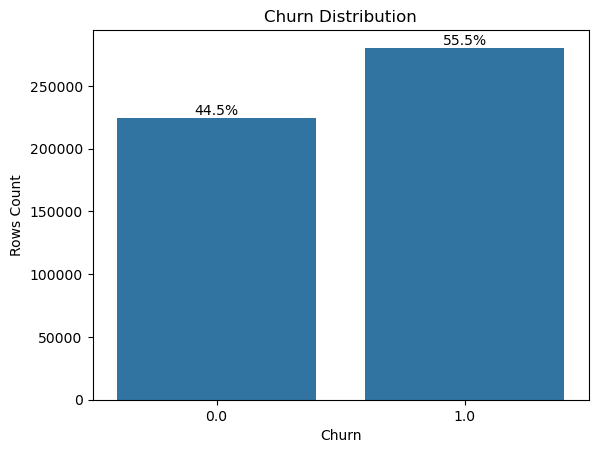

In [180]:
# Distribution plot
plt.figure()
churn_distribution.index = churn_distribution.index.map({0: 'Retained', 1: 'Churned'})

ax = sns.countplot(x='Churn', data=data)

# Add percentage labels on top
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y),
                ha='center', va='bottom')

plt.title("Churn Distribution")
plt.ylabel("Rows Count")
plt.show()

### **Demographic Analysis**

* #### **Age** 

In [181]:
# Create age groups
clean_data['Age_Group'] = pd.cut(
    clean_data['Age'],
    bins=[0, 18, 40, 60, 100],
    labels=['1-18', '19-40', '41-60', '61-100']
)

display(clean_data[['Age', 'Age_Group']].head())

,Age,Age_Group
0,30.0,19-40
1,65.0,61-100
2,55.0,41-60
3,58.0,41-60
4,23.0,19-40


In [182]:
# Total customers per age group
total_per_group = clean_data.groupby('Age_Group')['Churn'].count()

# Number of churned per group
churned_per_group = clean_data.groupby('Age_Group')['Churn'].sum()

# Number of retained per group
retained_per_group = total_per_group - churned_per_group

# Percentage churned
pct_churned = churned_per_group / total_per_group * 100

# Percentage retained
pct_retained = retained_per_group / total_per_group * 100

age_churn_summary = pd.DataFrame({
    'Total': total_per_group,
    'Churned': churned_per_group,
    'Stayed': retained_per_group,
    '% Churned': pct_churned.round(2),
    '% Stayed': pct_retained.round(2)
})

age_churn_summary

C:\Users\idrsb\AppData\Local\Temp\ipykernel_17192\73920290.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_per_group = clean_data.groupby('Age_Group')['Churn'].count()
C:\Users\idrsb\AppData\Local\Temp\ipykernel_17192\73920290.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churned_per_group = clean_data.groupby('Age_Group')['Churn'].sum()


,Total,Churned,Stayed,% Churned,% Stayed
Age_Group,,,,,
1-18,9493,5895.0,3598.0,62.10,37.90
19-40,254903,125795.0,129108.0,49.35,50.65
41-60,206446,117832.0,88614.0,57.08,42.92
61-100,34364,30970.0,3394.0,90.12,9.88


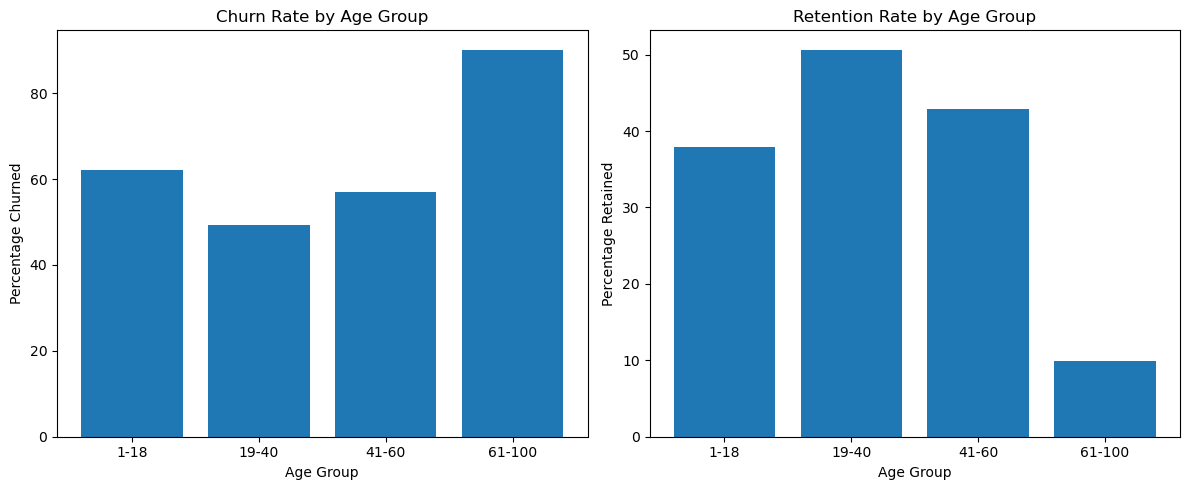

In [183]:
# Age Bar Chart Representation
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.bar(age_churn_summary.index.astype(str),
        age_churn_summary['% Churned'])
plt.xlabel('Age Group')
plt.ylabel('Percentage Churned')
plt.title('Churn Rate by Age Group')
plt.xticks(rotation=0)

plt.subplot(1,2,2)
plt.bar(age_churn_summary.index.astype(str),
        age_churn_summary['% Stayed'])
plt.xlabel('Age Group')
plt.ylabel('Percentage Retained')
plt.title('Retention Rate by Age Group')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


**Observation: Churn by Age Group**

* Customers aged **1-18** have a high churn rate of **62.1%**, suggesting that very young customers are less likely to remain subscribed.  
* The **19-40** age group shows a lower churn rate of **49.3%**, indicating relatively higher retention among young adults.  
* Customers aged **41-60** have a churn rate of **57.1%**, slightly higher than the 19-40 group, suggesting middle-aged customers are moderately at risk.  
* The **61-100** age group has an extremely high churn rate of **90.1%**, which might reflect inactive or one-time users, or possibly errors in data labeling.

**Key Insight:**  
Age clearly influences churn behavior. Both the youngest and oldest customer groups exhibit the highest churn, while young adults (19-40) are the most stable.


* #### **Gender** 

In [184]:
# Total count by gender
gender_total = clean_data['Gender'].value_counts()

# Percentage by gender
gender_percentage = clean_data['Gender'].value_counts(normalize=True) * 100

# Churn count 
gender_churn = clean_data.groupby('Gender')['Churn'].sum()

# Stayed count
gender_stayed = clean_data.groupby('Gender')['Churn'].count() - gender_churn

# Percentage churned
g_churn_prc = (gender_churn / gender_total) * 100

# Percentage retained 
g_stay_prc = (gender_stayed / gender_total) * 100

gender_summary = pd.DataFrame({
    'Total': gender_total,
    'Percentage (%)': gender_percentage.round(2),
    'Churned': gender_churn,
    'Stayed': gender_stayed,
    '% Churned': g_churn_prc.round(2),
    '% Stayed': g_stay_prc.round(2),
})
gender_summary

,Total,Percentage (%),Churned,Stayed,% Churned,% Stayed
Gender,,,,,,
0,224933,44.52,145969.0,78964.0,64.89,35.11
1,280273,55.48,134523.0,145750.0,48.00,52.00


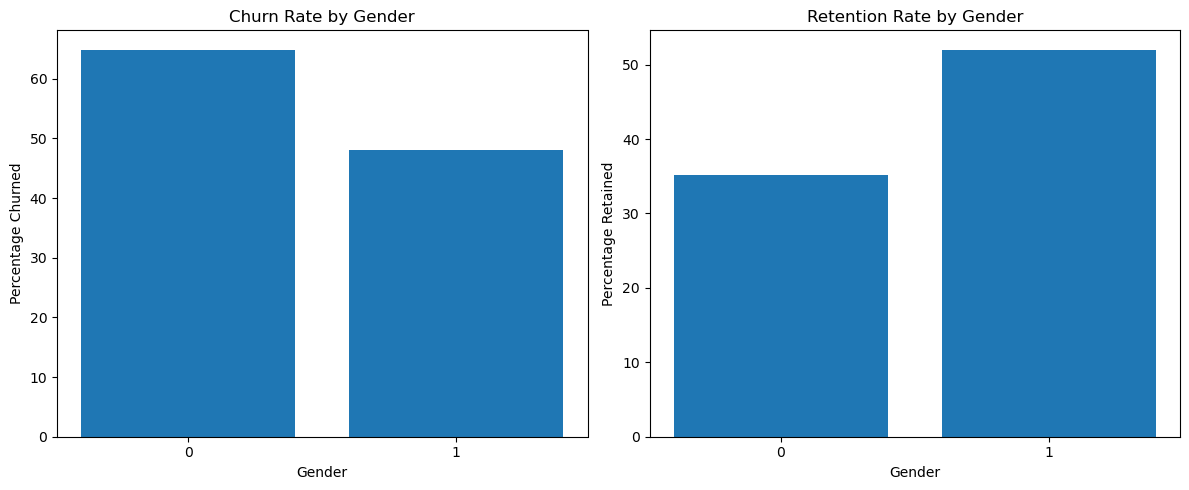

In [185]:
# Gender Bar Chart Representation
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.bar(gender_summary.index.astype(str),
        gender_summary['% Churned'])
plt.xlabel('Gender')
plt.ylabel('Percentage Churned')
plt.title('Churn Rate by Gender')
plt.xticks(rotation=0)

plt.subplot(1,2,2)
plt.bar(gender_summary.index.astype(str),
        gender_summary['% Stayed'])
plt.xlabel('Gender')
plt.ylabel('Percentage Retained')
plt.title('Retention Rate by Gender')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Observation: Churn by Gender**
* Customers in **Gender = 0 (Female)** represent **44.52%** of the total customer base, with a notably high churn rate of **64.89%**. Only **35.11%** of this group stayed, indicating a significant retention issue within this segment.
* Customers in **Gender = 1 (Male)** make up 55.48% of the total customer base and show a lower churn rate of **48.00%**, while **52.00% **remained. This suggests stronger retention performance compared to Gender = 0.

**Key Insight:**  
Gender appears to have a meaningful impact on churn behavior.**Female** customers are significantly more likely to churn compared to **Males**. This group needs more attention to improve retention.

### **Customer Engagement Analysis**

* #### **Usage Frequency** 

In [186]:
# Average Usage Frequency by Churn status
usage_summary = clean_data.groupby('Churn')['Usage Frequency'].agg(['mean', 'median', 'count'])
usage_summary

,mean,median,count
Churn,,,
0.0,16.227738,16.0,224714
1.0,15.303909,15.0,280492


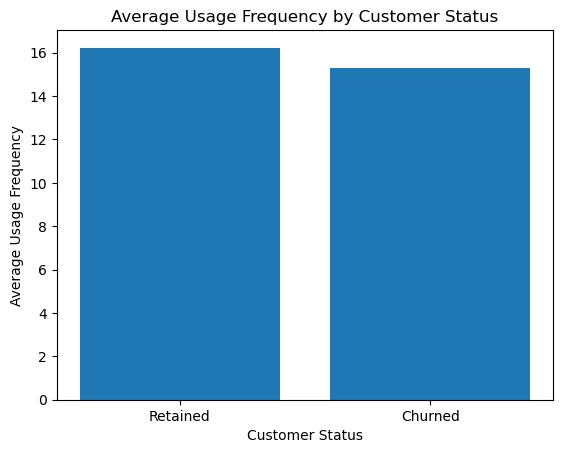

In [187]:
# Average Usage Frequency Bar Chart Representation
usage_summary.index = usage_summary.index.map({0: 'Retained', 1: 'Churned'})

plt.figure()

plt.bar(usage_summary.index,
        usage_summary['mean'])

plt.xlabel('Customer Status')
plt.ylabel('Average Usage Frequency')
plt.title('Average Usage Frequency by Customer Status')

plt.show()

**Observation: Average Usage Frequency by Churn Status**
* Customers who **stayed (Churn = 0)** have a slightly higher average usage frequency **(mean = 16.23, median = 16)** compared to those who churned.
* Customers who churned **(Churn = 1)** show a lower average usage frequency **(mean = 15.30, median = 15)**.
* The difference, although small, is consistent across both mean and median values, indicating that customers who use the service less frequently are slightly more likely to churn.

**Key Insight:**  
Lower usage frequency is associated with higher churn. Increasing customer engagement and encouraging more frequent usage may help improve retention.

* #### **Support Calls** 

In [188]:
# Average Support Calls  by Churn status
calls_summary = clean_data.groupby('Churn')['Support Calls'].agg(['mean', 'median', 'count'])
calls_summary

,mean,median,count
Churn,,,
0.0,2.025824,2.0,224714
1.0,5.281377,5.0,280492


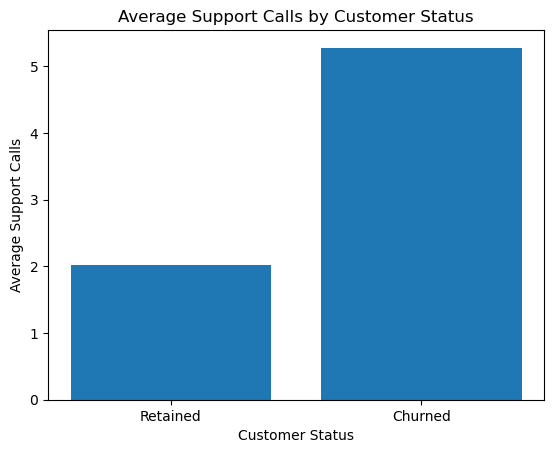

In [189]:
# Average Support Calls  Bar Chart Representation

calls_summary.index = calls_summary.index.map({0: 'Retained', 1: 'Churned'})

plt.figure()

plt.bar(calls_summary.index,
        calls_summary['mean'])

plt.xlabel('Customer Status')
plt.ylabel('Average Support Calls')
plt.title('Average Support Calls by Customer Status')

plt.show()

**Observation: Average Support Calls by Churn Status**
* Customers who **stayed (Churn = 0)** made an average of **2.03 support calls** (*median = 2*).
* Customers who **churned (Churn = 1)** made a significantly higher average of **5.28 support calls** (*median = 5*).
* The difference is substantial, with churned customers contacting support more than twice as often as retained customers.

**Key Insight:**  
Customers who contact support more frequently are much more likely to churn. High support interaction may indicate dissatisfaction or unresolved issues, making this a strong early warning signal for churn.

### **Financial Behavior Analysis**

* #### **Total Spend** 

In [190]:
# Total Spend by Churn status
spend_summary = clean_data.groupby('Churn')['Total Spend'].agg(['mean','median','count'])
spend_summary

,mean,median,count
Churn,,,
0.0,721.394858,733.00,224714
1.0,538.899354,529.43,280492


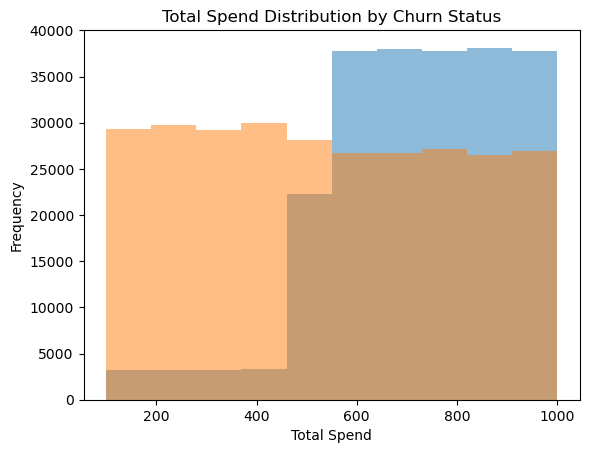

In [191]:
# Total Spend Chart Representation

plt.figure()

plt.hist(clean_data[clean_data['Churn'] == 0]['Total Spend'], alpha=0.5)
plt.hist(clean_data[clean_data['Churn'] == 1]['Total Spend'], alpha=0.5)

plt.xlabel('Total Spend')
plt.ylabel('Frequency')
plt.title('Total Spend Distribution by Churn Status')

plt.show()

**Observation: Total Spend Distribution by Churn Status**
* The **blue distribution (Stayed / Churn = 0)** is shifted more toward higher spending values **(around 600–1000)**, which matches the higher mean (**~721**).
* The **orange distribution (Churned / Churn = 1)** is more concentrated in the lower spending range **(around 100–600)**, aligning with the lower mean (**~539**).
* There is overlap, but the general shift confirms that retained customers tend to spend more.

**Key Insight:**  
Customers with lower total spend are more likely to churn, making low-spending customers a high-risk segment that may require targeted engagement strategies.

* #### **Payment Delay** 

In [192]:
# Average Payment Delay by Churn status
delay_summary = clean_data.groupby('Churn')['Payment Delay'].mean().round(2)

delay_summary

Churn
0.0    10.38
1.0    15.99
Name: Payment Delay, dtype: float64

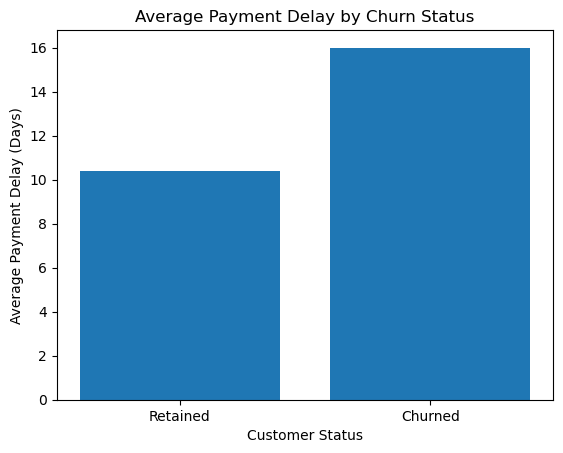

In [193]:
# Average Payment Delay Bar Chart Representation

delay_summary.index = delay_summary.index.map({0: 'Retained', 1: 'Churned'})

plt.figure()

plt.bar(delay_summary.index,
        delay_summary.values)

plt.xlabel('Customer Status')
plt.ylabel('Average Payment Delay (Days)')
plt.title('Average Payment Delay by Churn Status')

plt.show()

**Observation: Average Payment Delay by Churn Status**
* Customers who **stayed (Churn = 0)** have an average payment delay of **~ 10 days.**
* Customers who **churned (Churn = 1)** show a significantly higher average payment delay of **~ 16 days.**
* Churned customers, on average, delay payments by nearly **6 more days** compared to retained customers.

**Key Insight:**  
Longer payment delays are strongly associated with churn. Customers who frequently delay payments may be financially disengaged or dissatisfied, making payment delay a useful early warning indicator for churn risk.

### **Subscription & Contract Analysis**

* #### **Subscription Type** 

In [194]:
subscription_table = clean_data.groupby('Subscription Type')['Churn'].agg(
    Total='count',
    Churned='sum'
)

# Calculate Stayed
subscription_table['Stayed'] = subscription_table['Total'] - subscription_table['Churned']

# Percentages within each subscription type
subscription_table['% Churned'] = (
    subscription_table['Churned'] / subscription_table['Total']
) * 100

subscription_table['% Stayed'] = (
    subscription_table['Stayed'] / subscription_table['Total']
) * 100

# Round percentages
subscription_table['% Churned'] = subscription_table['% Churned'].round(2)
subscription_table['% Stayed'] = subscription_table['% Stayed'].round(2)

subscription_table

,Total,Churned,Stayed,% Churned,% Stayed
Subscription Type,,,,,
0,164477,93566.0,70911.0,56.89,43.11
1,170630,93793.0,76837.0,54.97,45.03
2,170099,93133.0,76966.0,54.75,45.25


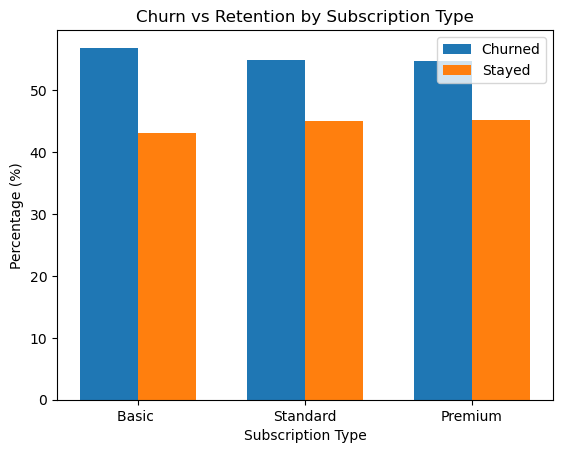

In [195]:
# Subscription Type Bar Chart Representation

subscription_table.index = subscription_table.index.map({0: 'Basic ', 1: 'Standard', 2: 'Premium'})

x = np.arange(len(subscription_table.index))
width = 0.35

plt.figure()

plt.bar(x - width/2, subscription_table['% Churned'], width)
plt.bar(x + width/2, subscription_table['% Stayed'], width)

plt.xticks(x, subscription_table.index.astype(str))
plt.xlabel('Subscription Type')
plt.ylabel('Percentage (%)')
plt.title('Churn vs Retention by Subscription Type')

plt.legend(['Churned', 'Stayed'])

plt.show()

**Observation: Churn by Subscription Type**
* Customers with **Subscription Type = 0 (Basic)** have a churn rate of **56.89%**, with **43.11%** staying.
* Customers with **Subscription Type = 1 (Standard)** show a slightly lower churn rate of **54.97%**, with **45.03%** remaining.
* Customers with **Subscription Type = 2 (Premium)** have the **lowest churn rate (54.75%)** and the **highest retention (45.25%**) among the three subscription types.

**Key Insight:**   
Churn rates are relatively similar across all subscription types, suggesting that subscription type alone may not be a strong factor driving churn.

* #### **Contract Length** 

In [196]:
contract_table = clean_data.groupby('Contract Length')['Churn'].agg(
    Total='count',
    Churned='sum'
)

# Stayed
contract_table['Stayed'] = contract_table['Total'] - contract_table['Churned']

# Percentages
contract_table['% Churned'] = (
    contract_table['Churned'] / contract_table['Total']
) * 100

contract_table['% Stayed'] = (
    contract_table['Stayed'] / contract_table['Total']
) * 100

# Round percentages
contract_table['% Churned'] = contract_table['% Churned'].round(2)
contract_table['% Stayed'] = contract_table['% Stayed'].round(2)

contract_table

,Total,Churned,Stayed,% Churned,% Stayed
Contract Length,,,,,
0,109234,98525.0,10709.0,90.20,9.80
1,197364,90426.0,106938.0,45.82,54.18
2,198608,91541.0,107067.0,46.09,53.91


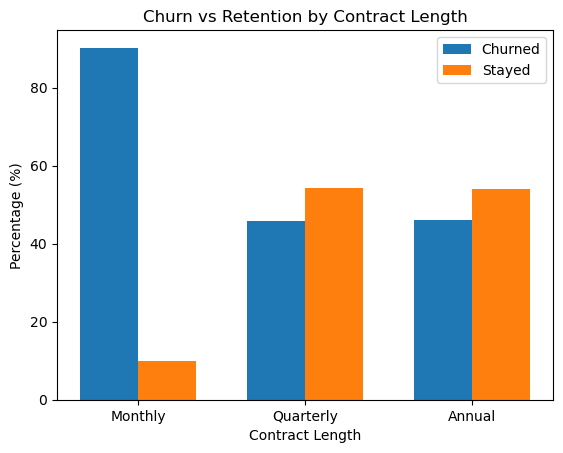

In [197]:
# Contract Length Bar Chart Representation

contract_table.index = contract_table.index.map({0: 'Monthly', 1: 'Quarterly', 2: 'Annual'})

x = np.arange(len(contract_table.index))
width = 0.35

plt.figure()

plt.bar(x - width/2, contract_table['% Churned'], width)
plt.bar(x + width/2, contract_table['% Stayed'], width)

plt.xticks(x, contract_table.index.astype(str))
plt.xlabel('Contract Length')
plt.ylabel('Percentage (%)')
plt.title('Churn vs Retention by Contract Length')

plt.legend(['Churned', 'Stayed'])

plt.show()

**Observation: Churn by Contract Length**

* Customers with **Contract Length = 0 (Monthly)** show an extremely high churn rate of **90.20%**, with only **9.80%** staying.
* Customers with **Contract Length = 1 (Quarterly)** have a significantly lower churn rate of **45.82%**, with **54.18%** remaining.
* Customers with **Contract Length = 2 (Annual)** show a very similar churn rate of **46.09%**, with **53.91%** staying.

**Key Insight:**   
Customers without longer contracts **(Contract Length = 0)** are far more likely to churn, suggesting that longer-term contracts help improve customer retention.

### **Customer Loyalty Analysis**

* #### **Tenure** 

In [198]:
# Average Tenure by Churn status

tenure_summary = clean_data.groupby('Churn')['Tenure'].mean()
tenure_summary

Churn
0.0    31.760789
1.0    31.021683
Name: Tenure, dtype: float64

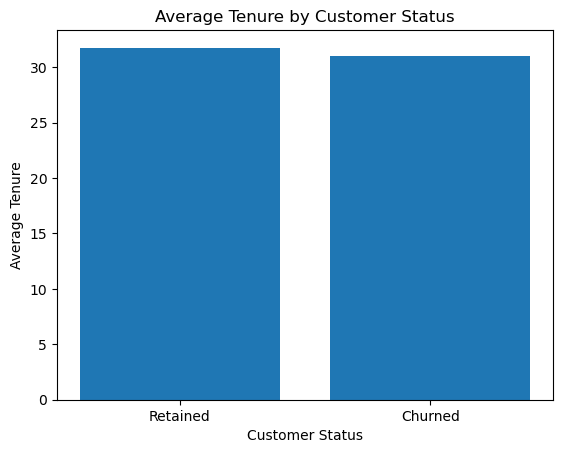

In [199]:
# Average Tenure Bar Chart Representation

tenure_summary.index = tenure_summary.index.map({0: 'Retained', 1: 'Churned'})

plt.figure()

plt.bar(tenure_summary.index,
        tenure_summary.values)

plt.xlabel('Customer Status')
plt.ylabel('Average Tenure')
plt.title('Average Tenure by Customer Status')

plt.show()

**Observation: Average Tenure by Churn Status**

* Customers who **stayed (Churn = 0)** have an average tenure of **31.76 months**.
* Customers who **churned (Churn = 1)** have a slightly lower average tenure of **31.02 months**.
* The difference between the two groups is very small, indicating that both new and long-term customers churn at similar levels.

**Key Insight:**   
Customer tenure does not appear to strongly influence churn, as the average tenure is nearly the same for both churned and retained customers.

## **Phase 4: Feature Engineering**

### **Engagement Intensity** 

In [200]:
# Create Engagement Score
clean_data['EngagementScore'] = clean_data['Usage Frequency'] - clean_data['Support Calls']

# Convert to categorical levels
clean_data['EngagementLevel'] = pd.cut(
    clean_data['EngagementScore'],
    bins=[-np.inf, 0, 10, np.inf],
    labels=['Low', 'Medium', 'High']
)
clean_data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age_Group,EngagementScore,EngagementLevel
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0,19-40,9.0,Medium
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0,61-100,-9.0,Low
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0,41-60,-2.0,Low
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0,41-60,14.0,High
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0,19-40,15.0,High


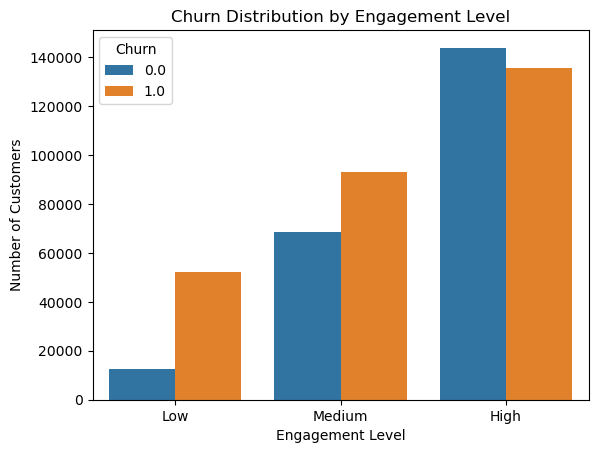

In [201]:
# Engagement Level Bar Chart Representation

plt.figure()

sns.countplot(x='EngagementLevel', hue='Churn', data=clean_data)

plt.title('Churn Distribution by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Number of Customers')

plt.show()

### **Average Spend per Tenure** 

In [202]:
# Create Average Spend Featutre 
clean_data['AvgSpend'] = clean_data['Total Spend'] / clean_data['Tenure']
clean_data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age_Group,EngagementScore,EngagementLevel,AvgSpend
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0,19-40,9.0,Medium,23.897436
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0,61-100,-9.0,Low,11.367347
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0,41-60,-2.0,Low,13.214286
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0,41-60,14.0,High,10.421053
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0,19-40,15.0,High,19.281250


### **Payment Risk** 

In [203]:
# Create a binary flag for customers with frequent payment delays
# Threshold set at 10 days based on distribution analysis
clean_data['LatePaymentFlag'] = (clean_data['Payment Delay'] > 10).astype(int)

clean_data.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age_Group,EngagementScore,EngagementLevel,AvgSpend,LatePaymentFlag
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0,19-40,9.0,Medium,23.897436,1
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0,61-100,-9.0,Low,11.367347,0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0,41-60,-2.0,Low,13.214286,1
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0,41-60,14.0,High,10.421053,0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0,19-40,15.0,High,19.281250,0


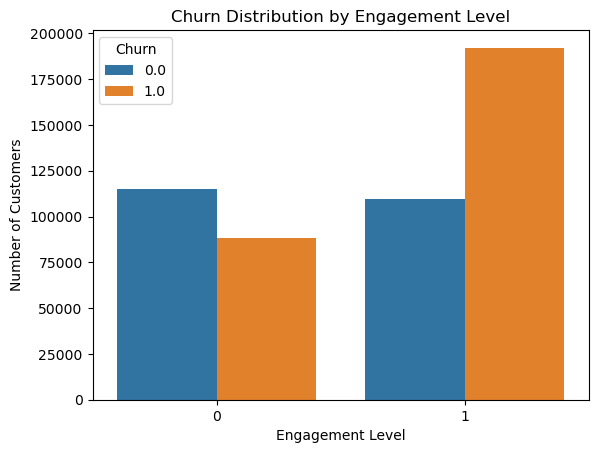

In [204]:
# Payment Risk Bar Chart Representation

plt.figure()

sns.countplot(x='LatePaymentFlag', hue='Churn', data=clean_data)

plt.title('Churn Distribution by Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Number of Customers')

plt.show()

### **Data Saving** 

In [205]:
# Save Cleaned Dataset
clean_data.to_csv("Data/Processed/Final_v_customer_churn_dataset.csv", index=False)

# Load Cleaned Dataset
clean_data = pd.read_csv("Data/Processed/Final_v_customer_churn_dataset.csv")
print("\nFinal Version Dataset Preview:")
display(clean_data.head())

print("\nDataset Shape:", clean_data.shape)


Final Version Dataset Preview:


,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Age_Group,EngagementScore,EngagementLevel,AvgSpend,LatePaymentFlag
0,30.0,0,39.0,14.0,5.0,18.0,1,2,932.0,17.0,1.0,19-40,9.0,Medium,23.897436,1
1,65.0,0,49.0,1.0,10.0,8.0,0,0,557.0,6.0,1.0,61-100,-9.0,Low,11.367347,0
2,55.0,0,14.0,4.0,6.0,18.0,0,1,185.0,3.0,1.0,41-60,-2.0,Low,13.214286,1
3,58.0,1,38.0,21.0,7.0,7.0,1,0,396.0,29.0,1.0,41-60,14.0,High,10.421053,0
4,23.0,1,32.0,20.0,5.0,8.0,0,0,617.0,20.0,1.0,19-40,15.0,High,19.281250,0



Dataset Shape: (505206, 16)
